정제 전 행 수: 891
정제 후 행 수: 891

[정제 전 결측치]
deck           688
age            177
embarked         2
embark_town      2
dtype: int64

[정제 후 결측치]
Series([], dtype: int64)

[수치형 변수 기술 통계]
          age    fare  family_size
count  891.00  891.00       891.00
mean    29.11   32.20         1.90
std     13.30   49.69         1.61
min      0.42    0.00         1.00
25%     21.50    7.91         1.00
50%     26.00   14.45         1.00
75%     36.00   31.00         2.00
max     80.00  512.33        11.00

[성별 생존율(%)]
        승객수  생존자수    생존율
sex                     
female  314   233  74.20
male    577   109  18.89

[객실 등급별 생존율(%)]
class
First     62.96
Second    47.28
Third     24.24
Name: survived, dtype: float64

[승선 항구별 생존율(%)]
embarked
C    55.36
Q    38.96
S    33.90
Name: survived, dtype: float64

[연령대별 생존율(%)]
age_group
어린이    57.97
청소년    41.05
성인     35.79
중년     38.43
노년     22.73
Name: survived, dtype: float64


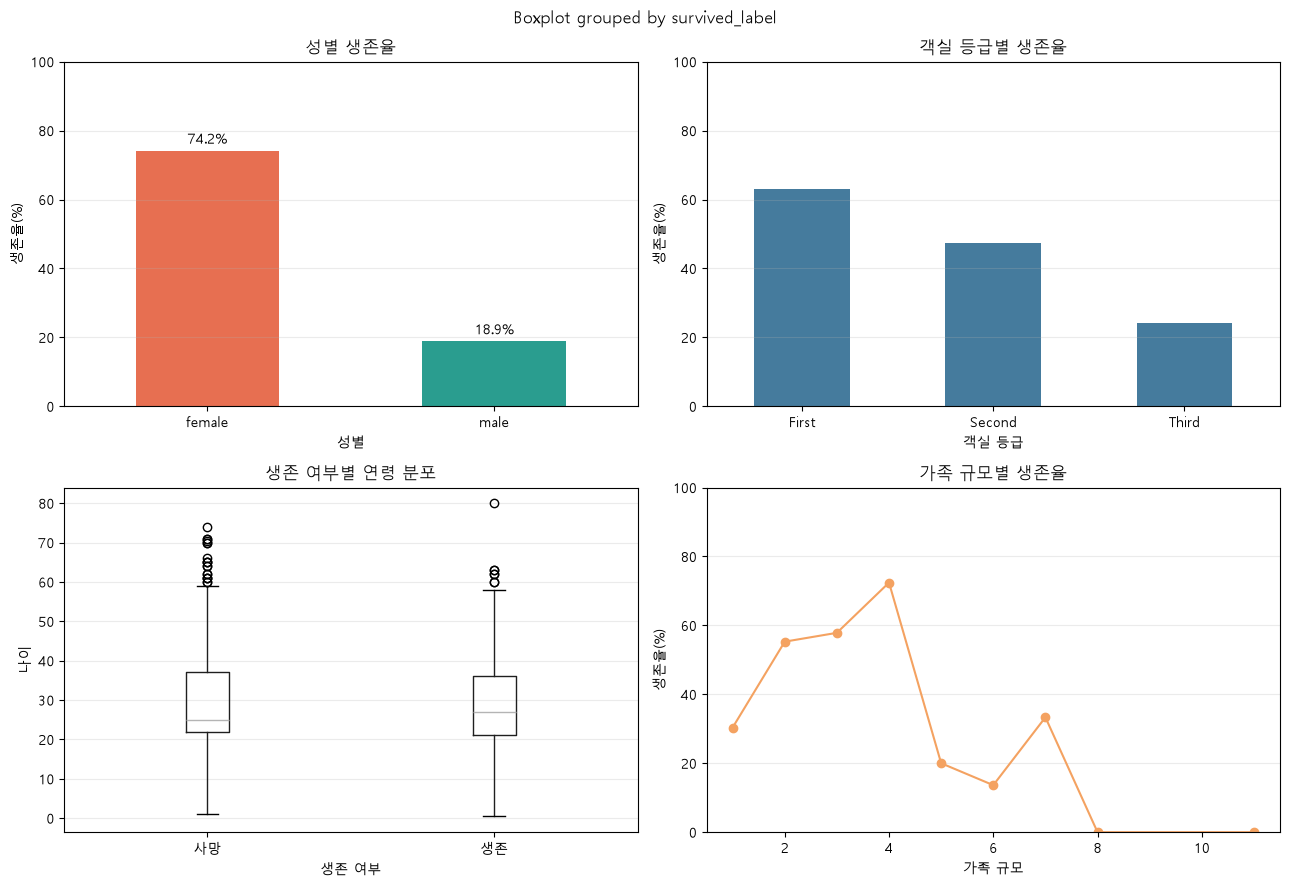


그래프 저장 완료: c:\work\titanic_analysis.png


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
OUTPUT_IMAGE = Path.cwd() / "titanic_analysis.png"


def load_titanic_data() -> pd.DataFrame:
    """인터넷에서 타이타닉 생존 데이터셋을 내려받습니다."""
    return pd.read_csv(DATA_URL)


def clean_titanic_data(data: pd.DataFrame) -> pd.DataFrame:
    """분석에 필요한 열을 선택하고 결측치와 잘못된 값을 정리합니다."""
    columns = [
        "survived", "pclass", "sex", "age", "sibsp", "parch", "fare",
        "embarked", "class", "alone",
    ]
    cleaned = data.loc[:, columns].copy()
    cleaned["sex"] = cleaned["sex"].str.strip().str.lower()
    cleaned["embarked"] = cleaned["embarked"].str.strip().str.upper()
    cleaned = cleaned.dropna(subset=["survived", "sex"])

    age_median = cleaned.groupby(["pclass", "sex"], observed=True)["age"].transform("median")
    cleaned["age"] = cleaned["age"].fillna(age_median).fillna(cleaned["age"].median())
    cleaned["fare"] = cleaned["fare"].fillna(cleaned["fare"].median())
    cleaned["embarked"] = cleaned["embarked"].fillna(cleaned["embarked"].mode().iloc[0])
    cleaned = cleaned[
        cleaned["age"].between(0, 100)
        & cleaned["fare"].ge(0)
        & cleaned["survived"].isin([0, 1])
        & cleaned["sex"].isin(["female", "male"])
    ].copy()

    cleaned["family_size"] = cleaned["sibsp"] + cleaned["parch"] + 1
    cleaned["age_group"] = pd.cut(
        cleaned["age"],
        bins=[0, 12, 19, 35, 60, 100],
        labels=["어린이", "청소년", "성인", "중년", "노년"],
        include_lowest=True,
    )
    cleaned["survived_label"] = cleaned["survived"].map({0: "사망", 1: "생존"})
    return cleaned.reset_index(drop=True)


raw_data = load_titanic_data()
missing_before = raw_data.isna().sum()
data = clean_titanic_data(raw_data)

print(f"정제 전 행 수: {len(raw_data)}")
print(f"정제 후 행 수: {len(data)}")
print("\n[정제 전 결측치]")
print(missing_before[missing_before.gt(0)].sort_values(ascending=False))
print("\n[정제 후 결측치]")
print(data.isna().sum().loc[lambda values: values.gt(0)])
print("\n[수치형 변수 기술 통계]")
print(data[["age", "fare", "family_size"]].describe().round(2))

sex_survival = data.groupby("sex", observed=True)["survived"].agg(
    승객수="count", 생존자수="sum", 생존율="mean"
)
sex_survival["생존율"] = (sex_survival["생존율"] * 100).round(2)
print("\n[성별 생존율(%)]")
print(sex_survival)
print("\n[객실 등급별 생존율(%)]")
print((data.groupby("class", observed=True)["survived"].mean() * 100).round(2))
print("\n[승선 항구별 생존율(%)]")
print((data.groupby("embarked", observed=True)["survived"].mean() * 100).round(2))
print("\n[연령대별 생존율(%)]")
print((data.groupby("age_group", observed=True)["survived"].mean() * 100).round(2))

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
figure, axes = plt.subplots(2, 2, figsize=(13, 9))
figure.suptitle("타이타닉 생존 데이터 다각도 분석", fontsize=18, fontweight="bold")

sex_survival["생존율"].plot(
    kind="bar", ax=axes[0, 0], color=["#e76f51", "#2a9d8f"], ylim=(0, 100), rot=0
)
axes[0, 0].set_title("성별 생존율")
axes[0, 0].set_xlabel("성별")
axes[0, 0].set_ylabel("생존율(%)")
for index, value in enumerate(sex_survival["생존율"]):
    axes[0, 0].text(index, value + 2, f"{value:.1f}%", ha="center")

class_survival = data.groupby("class", observed=True)["survived"].mean().mul(100)
class_survival.plot(kind="bar", ax=axes[0, 1], color="#457b9d", ylim=(0, 100), rot=0)
axes[0, 1].set_title("객실 등급별 생존율")
axes[0, 1].set_xlabel("객실 등급")
axes[0, 1].set_ylabel("생존율(%)")

data.boxplot(column="age", by="survived_label", ax=axes[1, 0], grid=False)
axes[1, 0].set_title("생존 여부별 연령 분포")
axes[1, 0].set_xlabel("생존 여부")
axes[1, 0].set_ylabel("나이")

family_survival = data.groupby("family_size", observed=True)["survived"].mean().mul(100)
family_survival.plot(kind="line", marker="o", ax=axes[1, 1], color="#f4a261")
axes[1, 1].set_title("가족 규모별 생존율")
axes[1, 1].set_xlabel("가족 규모")
axes[1, 1].set_ylabel("생존율(%)")
axes[1, 1].set_ylim(0, 100)

for axis in axes.flat:
    axis.grid(axis="y", alpha=0.25)
figure.tight_layout()
figure.savefig(OUTPUT_IMAGE, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n그래프 저장 완료: {OUTPUT_IMAGE}")